## Détermination des erreurs statistiques et systématiques

> Statistique de comptage

L'erreur statistque sur le taux de comptage $N_{J/\Psi}$ est donnée par la statistique poissonienne.

Soit $\lambda$ le nombre moyen de $J/\Psi$ produit sur un intevale de temps donné. Alors la probabilité de compter $k$ $J/\Psi$ dans cet intervalle de temps est:

$f(k,\lambda) = \frac{\lambda^k}{k!}e^{-\lambda}$

>Récap de la formule de la section efficace:

$\sigma_{J/\Psi} = \frac{N_{J/\Psi}^{cor}}{BR(J/\Psi \rightarrow l^+l^-)}\times \frac{\sigma_{MB}}{N_{MB}} $

Avec:

$N_{J/\Psi}^{cor} = N_{J/\Psi}/\left< A \times \varepsilon \right>$ où $ \left< A \times \varepsilon \right> = 20.6\% $ en moyenne $N_{J/\Psi} = 540.595 \pm 1.960$, et $\Delta \left< A \times \varepsilon \right> = \sqrt{\left< A \times \varepsilon \right> \times \frac{1+\left< A \times \varepsilon \right>}{N^{Gen}}}$

$BR(J/\Psi \rightarrow l^+l^-) =  (5.94 \pm 0.06)\%$ donc $\Delta BR(J/\Psi \rightarrow l^+l^-) = 0.06\%$

$\sigma_{MB} = 5̇7.52 \pm 0.03(\text{stat}) \pm 1.14(\text{syst}) \text{ mb}$ 

Ainsi en propageant sur le quotient, on trouve l'incertitude sur la section efficace:

$\Delta \sigma_{J/\Psi} = \sigma_{J/\Psi}\sqrt{ \left( \frac{\Delta N_{J/\Psi}}{N_{J/\Psi}} \right) ^2+ \left( \frac{\Delta BR(J/\Psi \rightarrow l^+l^-)}{BR(J/\Psi \rightarrow l^+l^-)} \right) ^2  + \left( \frac{\Delta \sigma_{MB} }{\sigma_{MB}} \right) ^2 + \left( \frac{\Delta N_{MB}}{N_{MB}} \right) ^2 + \left( \frac{\Delta \left< A\times \varepsilon \right> }{ \left< A\times \varepsilon \right>}\right)^2}$

> ébauche de code sur le calcul d'incertitude

In [5]:
import numpy as np
import scipy.stats as st

### Initialisation des données ###
N = 540.595
BR = 5.94/100
sigma_mb = 57.52
N_mb = 2593403501.051492
Ae = 20.6/100

### définition des erreurs relatives ###
u_N = 1.960
u_BR = 0.06/100
u_sigma_mb = np.sqrt(0.03**2 + 1.14**2)
u_N_mb = np.sqrt(N_mb)
u_Ae = 1

###
sigma = (N*sigma_mb)/(BR*N_mb*Ae)

def sigma_and_pm(sigma_JPsi):
    return (sigma_JPsi,sigma_JPsi*np.sqrt(pow(u_N/N,2) + pow(u_BR/BR,2) + pow(u_sigma_mb/sigma_mb,2) + pow(u_N_mb/N_mb,2)+ pow(u_Ae/Ae,2)))

sigma_and_pm(sigma)

(0.0009798670272088861, np.float64(0.0047566873497743925))

> 1) Calcul de l'intervale de confiance pour N

[4.46725813 1.01500694]
2.113588921896673


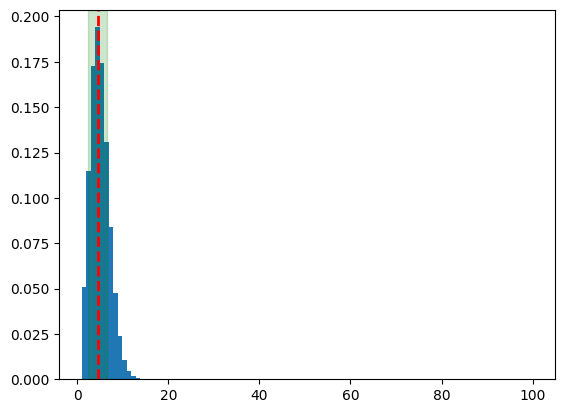

In [53]:
# Le but est de faire un fit d'une poissonienne sur la distribution du nombre N de JPSi sur un temps d'acquisition fixe
from scipy.special import factorial
        
#exemple avec une poissonienne toute faite
def poisson(k, lamb, scale):
    return scale*((lamb**k)/factorial(k))*np.exp(-lamb)
Max = 100
Poiss = []
from random import randint
for i in range(0,Max):
    for j in range(0,int(10000*poisson(i,4.5,1))):
        Poiss.append(i)
        
import matplotlib.pyplot as plt
counts, bins = np.histogram(Poiss,bins=Max,range=(1,Max),density=True)

#Maintenant on fait un fit sur une poissonienne pour espérer retomber sur lambd
from scipy.optimize import curve_fit
parameters, matrice = curve_fit(poisson,bins[:-1],counts,p0=[7.,1.] )
print(parameters)

#notre lambda est donc parameters[0] 

###Calcul de l'intervalle de confiance à 95%###
def N_err(lambd):
    return np.sqrt(lambd)

def IC(lambd):
    return [lambd - N_err(lambd),lambd+N_err(lambd)]

print(N_err(parameters[0]))
I = IC(parameters[0])

plt.hist(Poiss,bins,density = True)
plt.axvspan(I[0],I[1],color='green',alpha=0.2)
plt.axvline(x=parameters[0],color='red',linestyle='--',linewidth=2)

> Test avec les $N_{J/\Psi}$

In [54]:
import uproot
import awkward as ak
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import math
import hist
import vector
print("uproot version",uproot.__version__)
print("awkward version",ak.__version__)
print("numpy version",np.__version__)
print("matplotlib version",matplotlib.__version__)
print("hist version",hist.__version__)
print("vector version",vector.__version__)
import os

vector.register_awkward() 

uproot version 5.5.1
awkward version 2.7.2
numpy version 2.1.3
matplotlib version 3.9.0
hist version 2.8.0
vector version 1.5.2


In [62]:
#Exemple pour 1

file = uproot.open("/pbs/throng/training/nantes-m2-rps-exp/data/run291263.mc.root")  # runXXX.mc.root pour les donnees simulees

gen = file["genTree"]
m = gen.arrays(["nMuonsGen","Muon_GenPx","Muon_GenPy","Muon_GenPz","Muon_GenE","Muon_GenLabel","Muon_GenMotherPDGCode"]) 

events = file["eventsTree"]
n = events.arrays(["zVtx","isCMUL","nMuons","Muon_Px","Muon_Py","Muon_Pz","Muon_E","Muon_Charge","Muon_thetaAbs","Muon_matchedTrgThreshold","Muon_MCLabel"]) #10000 pour essayer a modifier apres

mask = (n["nMuons"] >= 2) & ak.all(m["Muon_GenMotherPDGCode"] == 443, axis=1)
inverse_mask = ~((n["nMuons"] >= 2) & ak.all(m["Muon_GenMotherPDGCode"] == 443, axis=1))

filtered_gem_events = m[ak.all(m["Muon_GenMotherPDGCode"] == 443, axis=1)]
filtered_events = n[mask & (n.isCMUL)&(abs(n.zVtx)<10)]
print(len(filtered_gem_events))
print(len(filtered_events))

folder_path = "/pbs/throng/training/nantes-m2-rps-exp/data"
j_psi_gen = []
j_psi_rec = []
results=[]
file_count =0

for file_name in os.listdir(folder_path):
    if file_name.endswith(".mc.root"):
        file_path = os.path.join(folder_path, file_name)
        results.append(file_name[0:-8])

        print(f"Traitement du fichier : {file_name}")
        file = uproot.open(file_path)

        gen = file["genTree"]
        m = gen.arrays([
            "nMuonsGen",
            "Muon_GenPx",
            "Muon_GenPy",
            "Muon_GenPz",
            "Muon_GenE",
            "Muon_GenLabel",
            "Muon_GenMotherPDGCode"
        ])

        nMuonsGen = 0
        for i in range(len(m)):
            info = m[i]["nMuonsGen"]
            nMuonsGen += info
        print("nMuonsGen = ", nMuonsGen)

        events = file["eventsTree"]
        n = events.arrays([
            "zVtx",
            "isCMUL",
            "nMuons",
            "Muon_Px",
            "Muon_Py",
            "Muon_Pz",
            "Muon_E",
            "Muon_Charge",
            "Muon_thetaAbs",
            "Muon_matchedTrgThreshold",
            "Muon_MCLabel"
        ])

        nMuons = 0
        for i in range(len(n)):
            info = n[i]["nMuons"]
            nMuons += info
        print("nMuons = ", nMuons)

        #-------------------------------------Pour 5 fichier seulement---------a supprimer plus tard (supprimer l'affichage surtout)--------------------
        file_count += 1
        if file_count >= 332 :
            print("Limite de fichiers atteinte.")
            break
            
        mask = (n["nMuons"] >= 2) & ak.all(m["Muon_GenMotherPDGCode"] == 443, axis=1)
        filtered_gem_events = m[ak.all(m["Muon_GenMotherPDGCode"] == 443, axis=1)]
        filtered_events = n[mask & (n.isCMUL)&(abs(n.zVtx)<10)]
        print(len(filtered_gem_events))
        print(len(filtered_events))
        j_psi_gen.append(len(filtered_gem_events))
        j_psi_rec.append(len(filtered_events))

100140
22801
Traitement du fichier : run292140.mc.root
nMuonsGen =  14000
nMuons =  7742
4681
943
Traitement du fichier : run290721.mc.root
nMuonsGen =  40000
nMuons =  21341
13419
2546
Traitement du fichier : run292160.mc.root
nMuonsGen =  260000
nMuons =  143259
86554
17549
Traitement du fichier : run291976.mc.root
nMuonsGen =  140000
nMuons =  77005
46668
9322
Traitement du fichier : run291944.mc.root
nMuonsGen =  100000
nMuons =  55365
33407
6860
Traitement du fichier : run291942.mc.root
nMuonsGen =  60000
nMuons =  33146
19909
4129
Traitement du fichier : run292062.mc.root
nMuonsGen =  240000
nMuons =  131802
80090
16296
Traitement du fichier : run291692.mc.root
nMuonsGen =  80000
nMuons =  44194
26744
5617
Traitement du fichier : run291283.mc.root
nMuonsGen =  80000
nMuons =  46241
26728
6229
Traitement du fichier : run292164.mc.root
nMuonsGen =  16000
nMuons =  8771
5346
1084
Traitement du fichier : run292270.mc.root
nMuonsGen =  80000
nMuons =  43746
26610
5459
Traitement du fi

[  252.    1379.45  2506.9   3634.35  4761.8   5889.25  7016.7   8144.15
  9271.6  10399.05 11526.5  12653.95 13781.4  14908.85 16036.3  17163.75
 18291.2  19418.65 20546.1  21673.55 22801.  ]


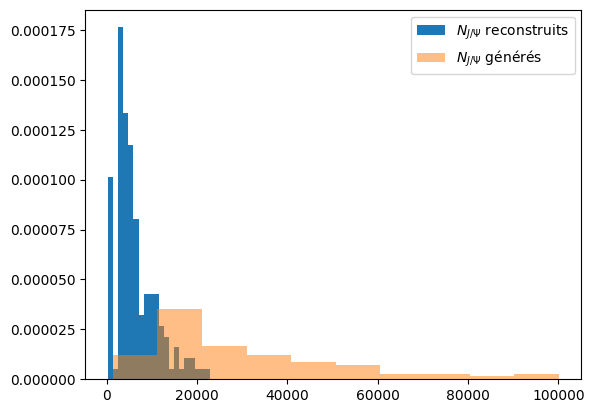

In [100]:
H_rec, Bin_rec = np.histogram(j_psi_rec,bins= 20)
H_gen, Bin_gen = np.histogram(j_psi_gen)
print(Bin_rec)
plt.hist(j_psi_rec,Bin_rec,label = r'$N_{J/\Psi}$ reconstruits', density = True)
plt.hist(j_psi_gen,Bin_gen,label = r'$N_{J/\Psi}$ générés',alpha= 0.5, density= True)
plt.legend()

In [101]:
parameters_gen, matrice_gen = curve_fit(poisson,Bin_gen[:-1],H_gen,p0=[2500.,1.])
parameters_rec, matrice_rec = curve_fit(poisson,Bin_rec[:-1],H_rec,p0=[15000.,1.])

print('lambda gen = ' + str(parameters_gen[0]) + ' et Shape_gen = ' + str(parameters_gen[1])  )
print('lambda rec =' + str(parameters_rec[0]) + ' et Shape_gen = ' + str(parameters_gen[1])  )

lambda gen = 2500.0 et Shape_gen = 1.0
lambda rec =15000.0 et Shape_gen = 1.0


/tmp/ipykernel_206/1707558856.py:6: RuntimeWarning: overflow encountered in power
  return scale*((lamb**k)/factorial(k))*np.exp(-lamb)
/tmp/ipykernel_206/1707558856.py:6: RuntimeWarning: invalid value encountered in divide
  return scale*((lamb**k)/factorial(k))*np.exp(-lamb)
/tmp/ipykernel_206/2263431398.py:1: OptimizeWarning: Covariance of the parameters could not be estimated
  parameters_gen, matrice_gen = curve_fit(poisson,Bin_gen[:-1],H_gen,p0=[2500.,1.])
/tmp/ipykernel_206/2263431398.py:2: OptimizeWarning: Covariance of the parameters could not be estimated
  parameters_rec, matrice_rec = curve_fit(poisson,Bin_rec[:-1],H_rec,p0=[15000.,1.])


Le fit avec la poissonienne ne donne rien à cause de la factorielle, on va donc simplement prendre la moyenne

In [102]:
def mean(L):
    if L == []:
        return 'error: empty list'
    else :
        return sum(L)/len(L)

In [103]:
M_rec, M_gen = mean(j_psi_rec), mean(j_psi_gen)
print(M_rec,M_gen)
print(Bin_rec)

6245.807228915663 30275.024096385543
[  252.    1379.45  2506.9   3634.35  4761.8   5889.25  7016.7   8144.15
  9271.6  10399.05 11526.5  12653.95 13781.4  14908.85 16036.3  17163.75
 18291.2  19418.65 20546.1  21673.55 22801.  ]


> Fonction finale pour l'err

In [ ]:
u_N = N_err_95(N,lambd)